C:\Users\User\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset directory: C:\Users\User\.cache\kagglehub\datasets\amiadesu\ukrainian-social-spam\versions\2
Found CSV files: [WindowsPath('C:/Users/User/.cache/kagglehub/datasets/amiadesu/ukrainian-social-spam/versions/2/spam.csv')]
Using file: C:\Users\User\.cache\kagglehub\datasets\amiadesu\ukrainian-social-spam\versions\2\spam.csv
Shape: (91386, 2)

Columns: ['text', 'spam']

Перші 5 рядків:


,text,spam
0,"__USER__ Це лека, і вона дуже крута, вона наша адміністраторка, я за тебе, тебе представлю",0
1,"У другому турі підтримав Віктора Ющенка, поставивши однією з головних умов підтримки впровадження політичної реформи...",0
2,"🪖 Твоя ідеальна підробітка? Знайдена. Без босів, без дзвінків, без офісу — тільки телефон і вільний час 💀 💵 25 000 г...",1
3,"🔹 ВАКАНСІЯ | АДМІНІСТРАТОР у центрі протезування“БЕЗ ОБМЕЖЕНЬ” (Київ, метро Нивки) Хочеш працювати у місці, де зміню...",1
4,__USER__ Відміть мене коли зможеш,0


Інформація про датасет:
<class 'pandas.DataFrame'>
RangeIndex: 91386 entries, 0 to 91385
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    91386 non-null  str  
 1   spam    91386 non-null  int64
dtypes: int64(1), str(1)
memory usage: 1.4 MB
Кількість унікальних значень у кожній колонці:


text    91386
spam        2
dtype: int64

...

text    0
spam    0
dtype: int64


Кількість повних дублікатів: 0
Розмір початкового датасету: (91386, 2)
Розмір після базового очищення: (91386, 2)
Кількість об'єктів у класах:


spam
0    65165
1    26221
Name: count, dtype: int64


Частка об'єктів у класах, %:


spam
0    71.31
1    28.69
Name: proportion, dtype: float64

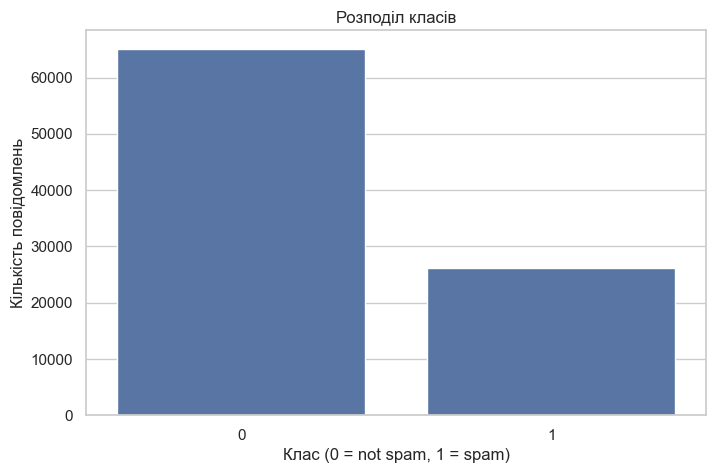

,count,mean,std,min,25%,50%,75%,max
length_chars,91386.0,154.018690,217.147132,21.0,44.0,80.0,168.0,4056.0
length_words,91386.0,24.566925,34.585820,1.0,8.0,13.0,25.0,833.0


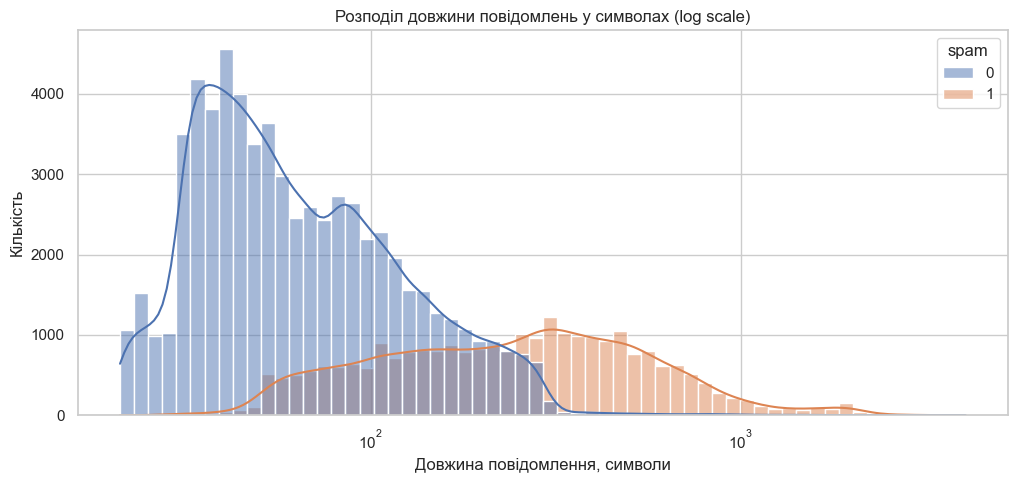

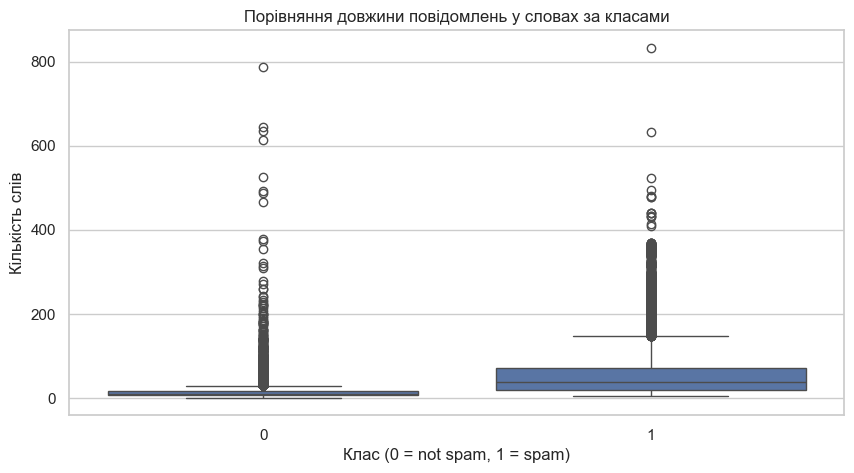

length_chars        length_words       
             mean median         mean median
spam                                        
0       81.212537   57.0    12.808885   10.0
1      334.958125  249.0    53.788261   39.0

ТОП-20 слів у spam:


,word,count
0,грн,40092
1,за,25337
2,на,24826
3,__url__,23411
4,в,19135
5,з,16603
6,від,15738
7,та,13352
8,2,10999
9,5,10087


ТОП-20 слів у not spam:


,word,count
0,в,17626
1,__user__,15491
2,на,15014
3,і,14067
4,я,13902
5,не,12661
6,з,10959
7,у,10188
8,та,6891
9,що,6783


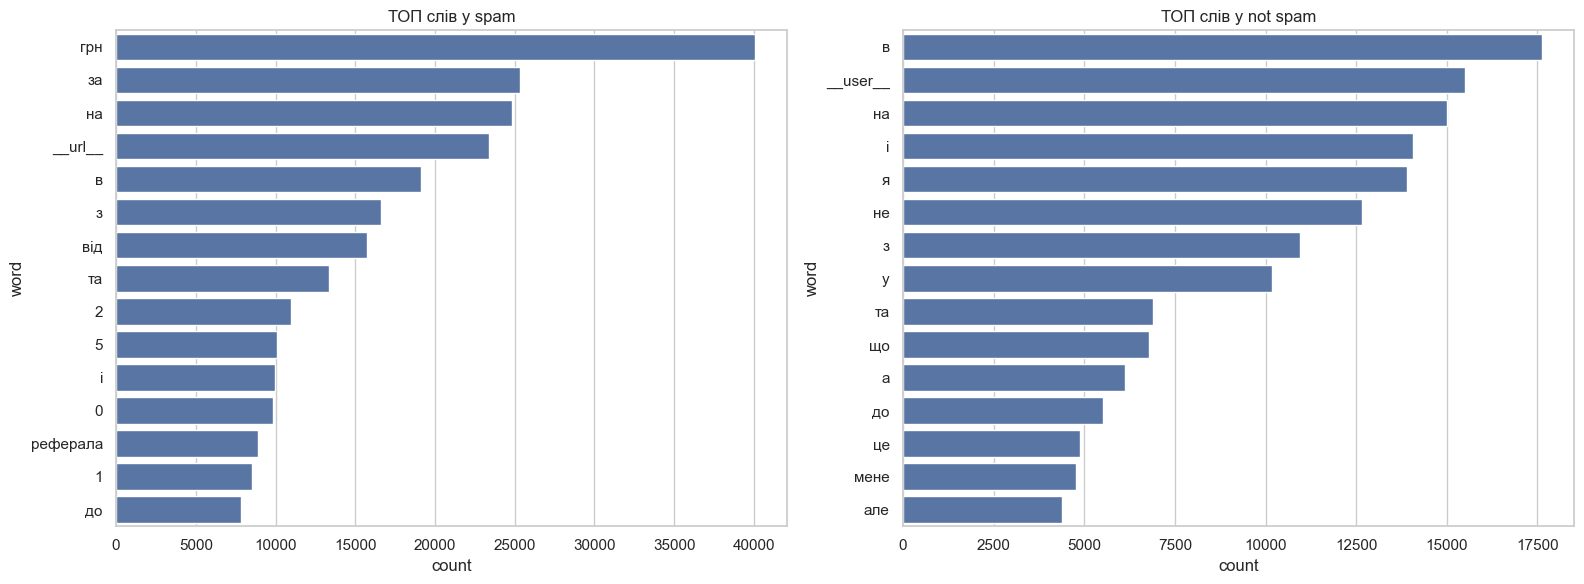

,has_url,has_special_chars,upper_ratio
spam,,,
0,0.001657,0.672416,0.094611
1,0.366767,0.964990,0.193680


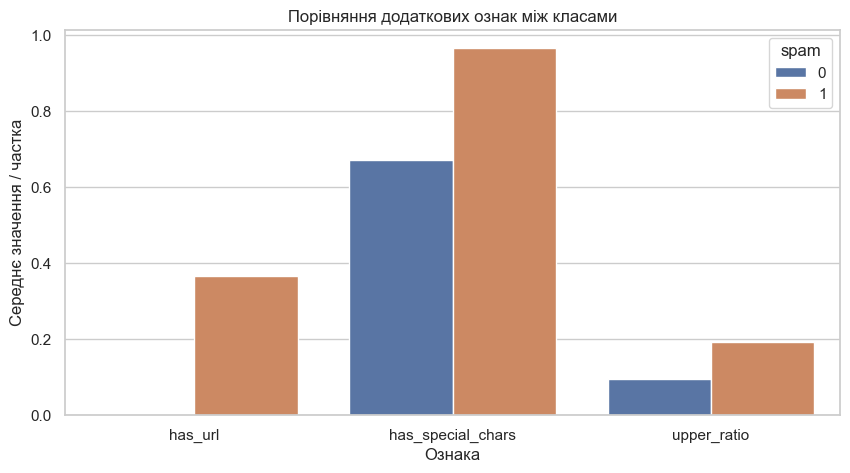

Train size: 73108
Test size: 18278

Розподіл класів у train, %:


spam
0    71.31
1    28.69
Name: proportion, dtype: float64


Розподіл класів у test, %:


spam
0    71.31
1    28.69
Name: proportion, dtype: float64

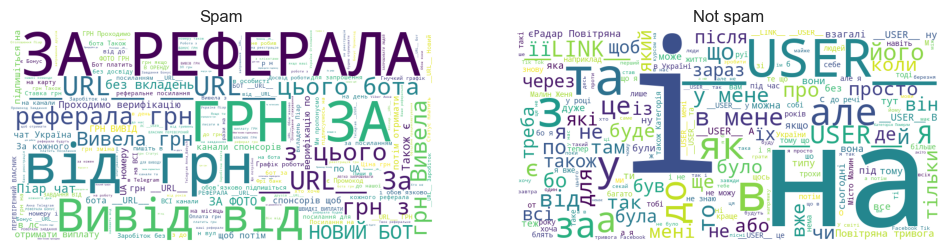

In [1]:
import re
import pandas as pd
import sys
sys.path.append('..')
from reworked_spam_eda_notebook import clean_text, X_train, X_test, y_train, y_test

In [2]:
# Видалення стоп-слів, лематизація, токенізація
import kagglehub
import nltk
from nltk.tokenize import word_tokenize
# nltk.download('punkt_tab')

path = kagglehub.dataset_download("heeraldedhia/stop-words-in-28-languages")

with open(r'C:\Users\User\.cache\kagglehub\datasets\heeraldedhia\stop-words-in-28-languages\versions\1\ukrainian.txt', 'r', encoding='utf-8') as f:
    stopwords = set(f.read().splitlines())
def remove_stopwords(text):
    if not isinstance(text, str):
        return ''
    
    # words = text.split()
    # прибираємо пунктуацію
    text = re.sub(r'[^\w\s]', '', text)
    tokens = word_tokenize(text) # токенізація
    filtered = [word for word in tokens if word.lower() not in stopwords]
    
    return ' '.join(filtered)
    
clean_text['text'] = clean_text.apply(remove_stopwords)
# clean_text.str.lower()

# print('\nNo stopwords:', clean_text['text'])

In [3]:
# Переведення тексту в вектор
# from sklearn.feature_extraction.text import TfidfVectorizer

# tfidf_vectorizer = TfidfVectorizer(lowercase=True, ngram_range=(1,1))
# train_tfidf = tfidf_vectorizer.fit_transform(X_train)
# test_tfidf = tfidf_vectorizer.transform(X_test)

In [4]:
# Логістична регресія
# from sklearn.linear_model import LogisticRegression
# # from sklearn import metrics

# model = LogisticRegression()
# model.fit(train_tfidf, y_train)
# # y_pred = model.predict(test_tfidf)

# # print(y_pred)
# # print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
# # print("Confusion Matrix:\n", metrics.confusion_matrix(y_test, y_pred))
# # print("Classification Report:\n", metrics.classification_report(y_test, y_pred))

Fitting 3 folds for each of 10 candidates, totalling 30 fits


C:\Users\User\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Best params: {'clf__C': np.float64(8.444214828324363), 'clf__penalty': 'l2', 'clf__solver': 'liblinear', 'tfidf__max_features': 25000, 'tfidf__ngram_range': (1, 2)}
Best CV score: 0.9845099459308067

Classification Report:

              precision    recall  f1-score   support

           0       0.99      1.00      0.99     13034
           1       0.99      0.98      0.99      5244

    accuracy                           0.99     18278
   macro avg       0.99      0.99      0.99     18278
weighted avg       0.99      0.99      0.99     18278

Model Accuracy: 0.99
Precision: 0.99
Recall: 0.98
F1-score: 0.99
ROC-AUC: 0.99
Confusion matrix:
 [[13007    27]
 [  116  5128]]


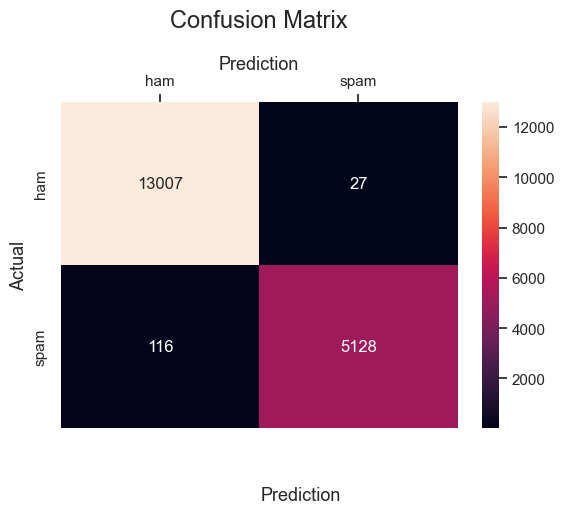

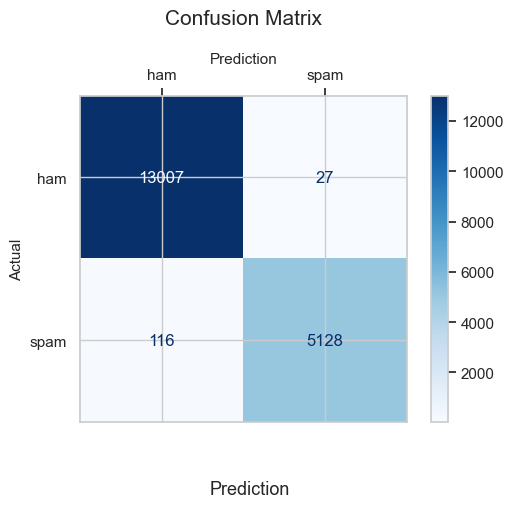

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from scipy.stats import uniform
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Pipeline: TF-IDF + Logistic Regression
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', LogisticRegression(random_state=0))
])

# Гіперпараметри
param_dist = {
    # TF-IDF
    'tfidf__ngram_range': [(1,2)],
    'tfidf__max_features': [25000],

    # Logistic Regression
    'clf__C': uniform(0.01, 9.99),
    'clf__penalty': ['l1', 'l2'],
    'clf__solver': ['liblinear']  # підтримує l1 і l2
}

# Randomized Search
random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=10,          # можна збільшити (20-50 для кращого результату)
    cv=3,
    verbose=1,
    random_state=0,
    n_jobs=-1,
    scoring='f1'        # важливо для задачі спаму
)

# Навчання
random_search.fit(X_train, y_train)

# Найкращі параметри
print("Best params:", random_search.best_params_)
print("Best CV score:", random_search.best_score_)

# Найкраща модель
best_model = random_search.best_estimator_

# Прогноз
y_pred = best_model.predict(X_test)

# Оцінка
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

y_pred = random_search.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1_score = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-score: {f1_score:.2f}")
print(f"ROC-AUC: {roc_auc:.2f}")
print('Confusion matrix:\n', cm)
sns.heatmap(cm, 
            annot=True,
            fmt='g', 
            xticklabels=['ham','spam'],
            yticklabels=['ham','spam'])
plt.ylabel('Actual', fontsize=13)
plt.title('Confusion Matrix', fontsize=17, pad=20)
plt.gca().xaxis.set_label_position('top') 
plt.xlabel('Prediction', fontsize=13)
plt.gca().xaxis.tick_top()

plt.gca().figure.subplots_adjust(bottom=0.2)
plt.gca().figure.text(0.5, 0.05, 'Prediction', ha='center', fontsize=13)
plt.show()

classes = ['ham', 'spam']
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix', fontsize=15, pad=20)
plt.xlabel('Prediction', fontsize=11)
plt.ylabel('Actual', fontsize=11)
plt.gca().xaxis.set_label_position('top')
plt.gca().xaxis.tick_top()
plt.gca().figure.subplots_adjust(bottom=0.2)
plt.gca().figure.text(0.5, 0.05, 'Prediction', ha='center', fontsize=13)

plt.show()

In [43]:
print(random_search.best_params_)
tfidf_params = {'max_features': 100, 'ngram_range': (1, 2)}
best_params = {'C': np.float64(8.444214828324363), 'penalty': 'l2', 'solver': 'liblinear'}

{'clf__C': np.float64(8.444214828324363), 'clf__penalty': 'l2', 'clf__solver': 'liblinear', 'tfidf__max_features': 25000, 'tfidf__ngram_range': (1, 2)}


In [44]:
from sklearn.metrics import f1_score as f1_metric

tfidf_vectorizer = TfidfVectorizer(lowercase=True, **tfidf_params)
train_tfidf = tfidf_vectorizer.fit_transform(X_train)
test_tfidf = tfidf_vectorizer.transform(X_test)
model = LogisticRegression(**best_params)
model.fit(train_tfidf, y_train)

y_pred = model.predict(test_tfidf)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1_score = f1_metric(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-score: {f1_score:.2f}")
print(f"ROC-AUC: {roc_auc:.2f}")
print('Confusion matrix:\n', cm)

C:\Users\User\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Model Accuracy: 0.97
Precision: 0.98
Recall: 0.92
F1-score: 0.95
ROC-AUC: 0.95
Confusion matrix:
 [[12920   114]
 [  436  4808]]


In [45]:
tmp = tfidf_vectorizer.transform(['продам гараж'])
model.predict(tmp)

array([0])

In [16]:
from sklearn.metrics import f1_score as f1_metric

# y_base = np.zeros((X_test.shape[0], 1), dtype=int)
y_base = np.where(np.random.random_sample(size=y_test.shape[0]) > 0.5, 1, 0)

accuracy = accuracy_score(y_test, y_base)
precision = precision_score(y_test, y_base)
recall = recall_score(y_test, y_base)
f1 = f1_metric(y_test, y_base)
roc_auc = roc_auc_score(y_test, y_base)
cm = confusion_matrix(y_test, y_base)

print(f"Model Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-score: {f1:.2f}")
print(f"ROC-AUC: {roc_auc:.2f}")
print('Confusion matrix:\n', cm)

Model Accuracy: 0.50
Precision: 0.29
Recall: 0.50
F1-score: 0.36
ROC-AUC: 0.50
Confusion matrix:
 [[6557 6477]
 [2629 2615]]


In [15]:
y_test.value_counts(normalize=True)

spam
0    0.713098
1    0.286902
Name: proportion, dtype: float64